# The Importance of Data Visualization in Data Science

**Objective:** This notebook demostrates why data visualization is essential in data science, using the famous **Anscombe's Quartet** dataset that shows how datasets with nearly identical statistical properties can have completely different distributions.

In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Adjust settings
warnings.filterwarnings('ignore')
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Introduction to Anscombe's Quartet

**Anscombe's Quartet** is a collection of four datasets that have nearly identical simple descriptive statistics (mean, variance, correlation, etc.), but appear very different when graphed.

This demonstrates why **data visualization** is essential - summary statistics alone can be misleading!

In [2]:
# Load Anscombe's Quartet dataset:
anscombe = sns.load_dataset("anscombe")
print("======== Anscombe's Quartet Dataset ========")
print(anscombe.head(12))

======== Anscombe's Quartet Dataset ========
   dataset     x      y
0        I  10.0   8.04
1        I   8.0   6.95
2        I  13.0   7.58
3        I   9.0   8.81
4        I  11.0   8.33
5        I  14.0   9.96
6        I   6.0   7.24
7        I   4.0   4.26
8        I  12.0  10.84
9        I   7.0   4.82
10       I   5.0   5.68
11      II  10.0   9.14


In [3]:
# Examine the structure of the data set
print("======== Dataset Structure ========")
print(f"Shape: {anscombe.shape}")
print(f"Dataset column names: {anscombe.columns.to_list()}")
print(f"Unique datasets: {anscombe['dataset'].unique()}")

======== Dataset Structure ========
Shape: (44, 3)
Dataset column names: ['dataset', 'x', 'y']
Unique datasets: ['I' 'II' 'III' 'IV']


## Statistical Summary of All Four Datasets

Let's first calculate the key statistical properties for each dataset to see how similar they appear numerically:

In [4]:
# Calculate summary statistics for each dataset
summary_stats = []
dataset_names = anscombe['dataset'].unique()

for dataset_name in dataset_names:

    subset = anscombe[anscombe['dataset'] == dataset_name]
    linreg_result = stats.linregress(subset['x'], subset['y'])
    
    stats_dict = {
        'Dataset': dataset_name,
        'Mean X': np.mean(subset['x']),
        'Mean Y': np.mean(subset['y']),
        'Variance X': np.var(subset['x'], ddof=1), # Sample variance
        'Variance Y': np.var(subset['y']),
        'Correlation': subset['x'].corr(subset['y']),
        'Linear Regression Slope': linreg_result.slope,
        'Linear Regression Intercept': linreg_result.intercept,
        'R-squared': linreg_result.rvalue**2
    }
    summary_stats.append(stats_dict)

# Create summary dataframe
summary_df = pd.DataFrame(summary_stats)
print("======== Statistical Summary of All Four Datasets ========")
print(summary_df.round(3))

======== Statistical Summary of All Four Datasets ========
  Dataset  Mean X  Mean Y  Variance X  Variance Y  Correlation  \
0       I     9.0   7.501        11.0       3.752        0.816   
1      II     9.0   7.501        11.0       3.752        0.816   
2     III     9.0   7.500        11.0       3.748        0.816   
3      IV     9.0   7.501        11.0       3.748        0.817   

   Linear Regression Slope  Linear Regression Intercept  R-squared  
0                      0.5                        3.000      0.667  
1                      0.5                        3.001      0.666  
2                      0.5                        3.002      0.666  
3                      0.5                        3.002      0.667  


## The Critical Insight: Visualizing the Dataset

Now let's plot all four datasets to reveal their true nature:

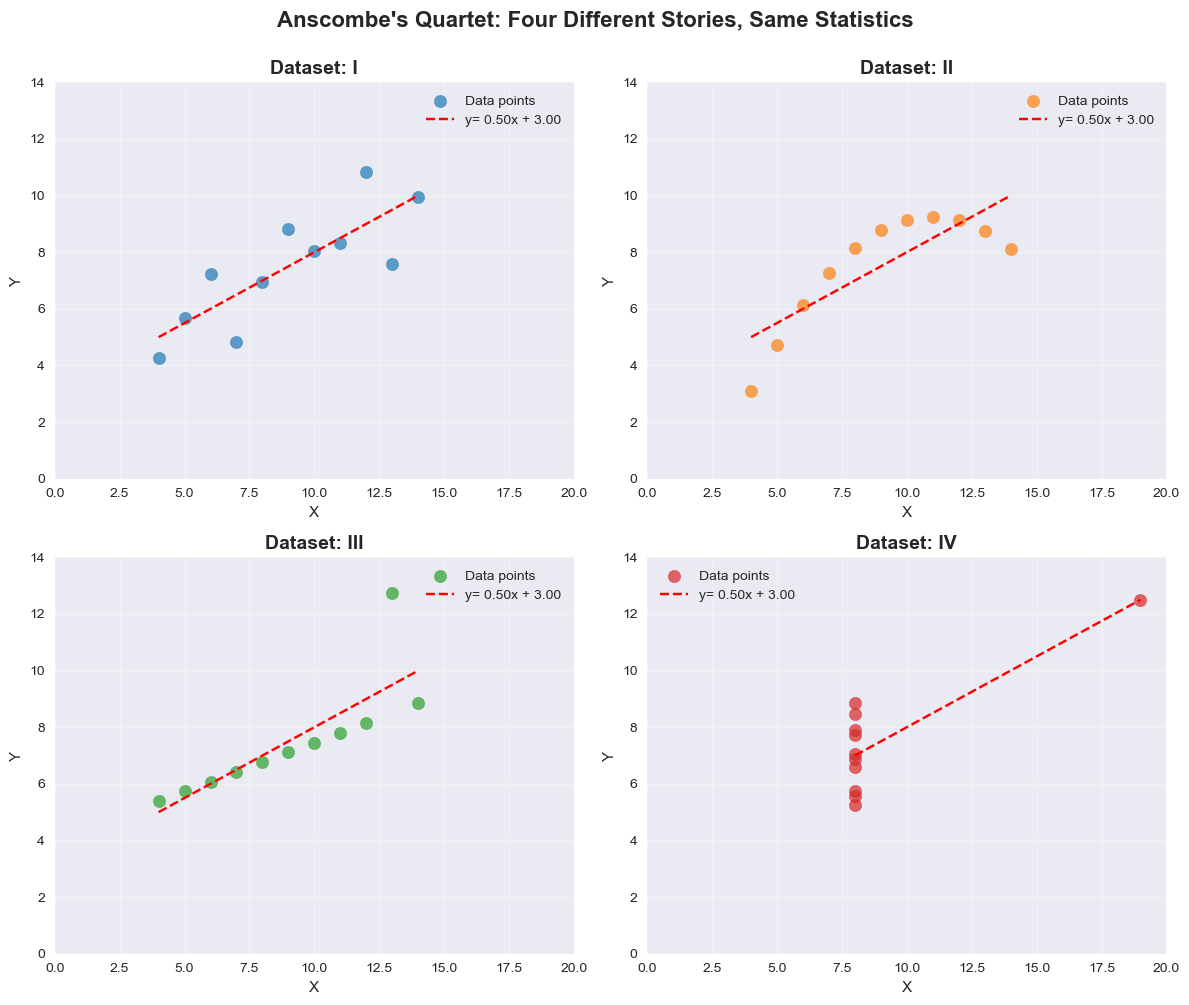

In [5]:
# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Anscombe's Quartet: Four Different Stories, Same Statistics", fontsize=16, fontweight="bold", y=1)

# Colors for different datasets
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']


for i, dataset_name in enumerate(dataset_names):

    row = i // 2
    col = i % 2

    subset = anscombe[anscombe['dataset'] == dataset_name]
    linreg_result = stats.linregress(subset['x'], subset['y'])
    slope, intercept, r_value, p_value, std_err = linreg_result

    # Plot the data points
    axes[row, col].scatter(subset['x'], subset['y'], color=colors[i], s=80, alpha=0.7, label='Data points')

    # Add regression line
    x_line = np.array([subset['x'].min(), subset['x'].max()])
    y_line = intercept + slope * x_line
    axes[row, col].plot(x_line, y_line, color='red', linestyle='--', label=f"y= {slope:.2f}x + {intercept:.2f}")

    # Customize each subplot
    axes[row, col].set_title(f"Dataset: {dataset_name}", fontsize=14, fontweight="bold")
    axes[row, col].set_xlabel('X')
    axes[row, col].set_ylabel('Y')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

    # Set consistent axis limits for better comparison
    axes[row, col].set_xlim(0, 20)
    axes[row, col].set_ylim(0, 14)

plt.tight_layout()
plt.show()

## Detailed Analysis of Each Dataset

Let's analyze each dataset individually for more detail:

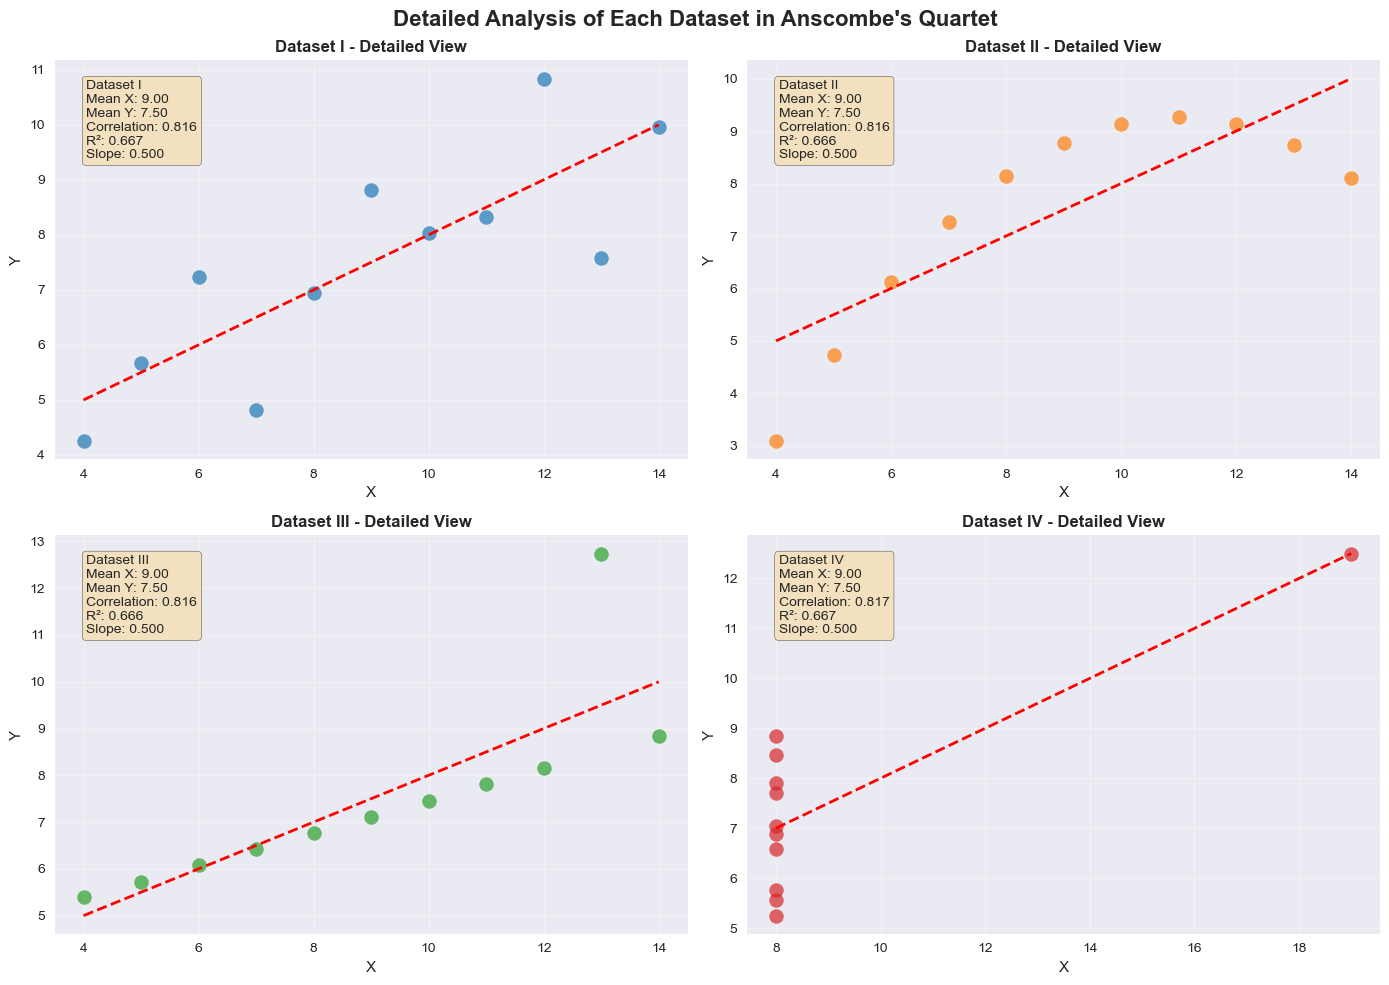

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, dataset_name in enumerate(dataset_names):
    row = i // 2
    col = i % 2
    
    subset = anscombe[anscombe['dataset'] == dataset_name]
    linreg_result = stats.linregress(subset['x'], subset['y'])
    slope, intercept, r_value, p_value, std_err = linreg_result
    
    # Main scatter plot
    scatter = axes[row, col].scatter(subset['x'], subset['y'], color=colors[i], s=100, alpha=0.7)
    
    # Regression line
    x_line = np.linspace(subset['x'].min(), subset['x'].max(), 100)
    y_line = intercept + slope * x_line
    axes[row, col].plot(x_line, y_line, color='red', linewidth=2, linestyle='--')
    
    # Add statistical annotations
    stats_text = f'''Dataset {dataset_name}
Mean X: {np.mean(subset['x']):.2f}
Mean Y: {np.mean(subset['y']):.2f}
Correlation: {r_value:.3f}
R²: {r_value**2:.3f}
Slope: {slope:.3f}'''
    
    axes[row, col].text(0.05, 0.95, stats_text, transform=axes[row, col].transAxes, 
                       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    axes[row, col].set_title(f'Dataset {dataset_name} - Detailed View', fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('X')
    axes[row, col].set_ylabel('Y')
    axes[row, col].grid(True, alpha=0.3)

plt.suptitle('Detailed Analysis of Each Dataset in Anscombe\'s Quartet', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## What Each Dataset Reveals

Here's a comprehensive analysis on what each dataset reveal:

#### Dataset I:
- Appears to be a well-behaved linear relationship
- Points are scattered randomly around the regression line
- This is what we typically hope to see in linear regression

#### Dataset II:
- Shows a clear non-linear (curved) pattern
- A linear model is inappropriate here
- A polynomial or other non-linear model would be better

#### Dataset III:
- Demonstrates the effect of a single outlier
- One point dramatically influences the regression line
- Highlights the importance of outlier detection

#### Dataset IV:
- Shows how a single influential point can drive correlation
- Without that one point, there's no relationship between X and Y
- Emphasizes the need to check for influential observations

## Statistical Tests and Residual Analysis

Let's perform a residual analysis to further demostrate the differences:

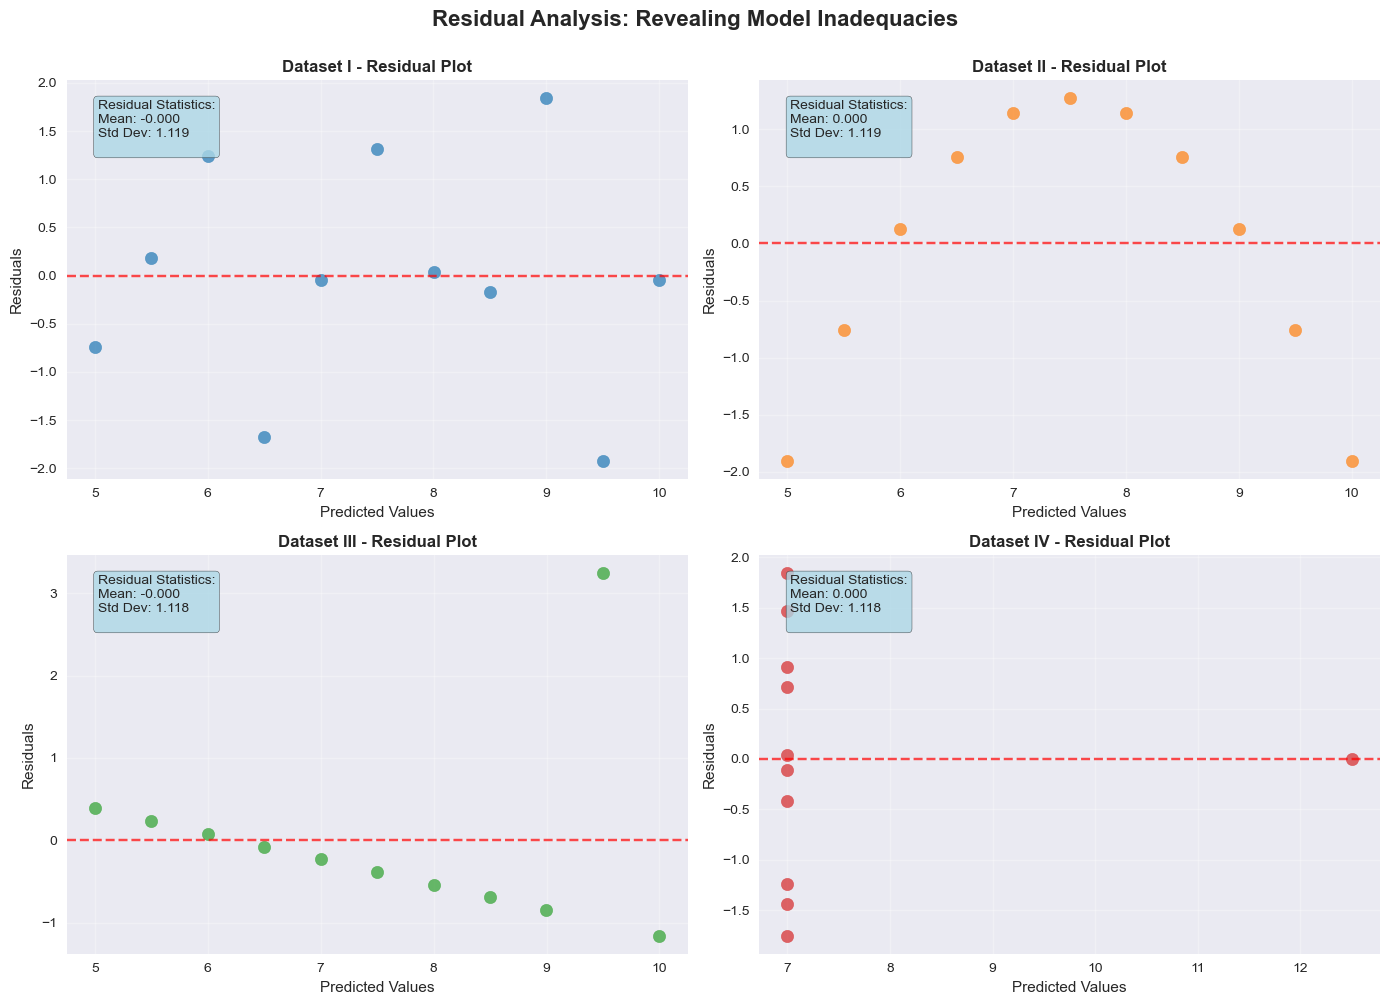

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, dataset_name in enumerate(dataset_names):
    row = i // 2
    col = i % 2
    
    subset = anscombe[anscombe['dataset'] == dataset_name]
    linreg_result = stats.linregress(subset['x'], subset['y'])
    slope, intercept, r_value, p_value, std_err = linreg_result

    # Calculate regression and residuals
    predicted = intercept + slope * subset['x']
    residuals = subset['y'] - predicted
    
    # Plot residuals
    axes[row, col].scatter(predicted, residuals, color=colors[i], s=80, alpha=0.7)
    axes[row, col].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[row, col].set_title(f'Dataset {dataset_name} - Residual Plot', fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('Predicted Values')
    axes[row, col].set_ylabel('Residuals')
    axes[row, col].grid(True, alpha=0.3)
    
    # Add residual statistics
    resid_text = f'''Residual Statistics:
Mean: {np.mean(residuals):.3f}
Std Dev: {np.std(residuals):.3f}
'''
    axes[row, col].text(0.05, 0.95, resid_text, transform=axes[row, col].transAxes, 
                       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.suptitle('Residual Analysis: Revealing Model Inadequacies', fontsize=16, fontweight='bold', y=1)
plt.tight_layout()
plt.show()

## Key Lessons for Data Science

#### 1. Summary statistics can be deceptive
   - Identical means, variances, and correlations can hide completely different data patterns
   - Never rely solely on numerical summaries  

#### 2. Visualization reveals true relationships
   - Plots show non-linearity, outliers, and patterns that statistics miss
   - Always visualize your data before modeling

#### 3. Outliers can dominate analysis
   - Single points can dramatically influence statistical measures
   - Check for influential points and outliers

#### 4. Residual analysis is crucial
   - Patterns in residuals reveal model inadequacies
   - Always examine residuals after fitting models

#### 5. Context matters
   - The same statistics can represent very different real-world scenarios
   - Understand the domain and context of your data

## Practical Recommendations for Data Scienctists

1. Always create scatter plots for continuous variable relationships
2. Examine residual plots after model fitting
3. Look for patterns, clusters, and outliers in visualizations
4. Use multiple visualization types (histograms, box plots, scatter plots)
5. Check for non-linear relationships
6. Verify homogeneity of variance
7. Look for influential points that distort relationships
8. Compare visual patterns with statistical summaries
9. Use interactive visualizations for exploration
10. Document and share visual insights with stakeholders

## Conclusion

Anscombe's Quartet powerfully demonstrates that:
- Numerical summaries alone are insufficient
- Data visualization is not optional - it's essential
- The human eye can detect patterns that statistics miss
- Always visualize before, during, and after analysis

As data scientists, we must make visualization a fundamental part of our exploratory data analysis and model validation process.

> **REMEMBER:**
> If Francis Anscombe taught us anything in 1973, it's that you should ALWAYS PLOT YOUR DATA!

---
**Next:** [Logistic Regression: Introduction](./05_logictic_regression--introduction.md)